#FARHANKHAN F. PATHAN
# ROLL NO. 61
# CSAI D-3

**Assignment 8**. Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing details of customers to predict customer response for special offer. Create confusion matrix based on above data and find

Accuracy
Precision
Recall
F-1 score

Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.datasets import make_classification

Creating DataFrame

In [ ]:
data = {
    "Age": [22,35,28,45,33,52,26,41,30,38,27,48,29,36,31,44,25,39,34,50],
    "Annual_Income": [300000,800000,450000,1000000,600000,1200000,350000,950000,500000,700000,400000,1100000,480000,750000,520000,980000,370000,680000,620000,1050000],
    "Spending_Score": [75,40,65,30,85,25,70,45,90,55,80,35,60,50,88,42,72,58,77,33],
    "Purchase_Frequency": [8,3,7,2,10,1,9,4,12,5,8,2,6,4,11,3,9,5,10,2],
    "Gender": [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0],
    "Response": [1,0,1,0,1,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0]
}

df = pd.DataFrame(data)

df

,Age,Annual_Income,Spending_Score,Purchase_Frequency,Gender,Response
0,22,300000,75,8,1,1
1,35,800000,40,3,0,0
2,28,450000,65,7,1,1
3,45,1000000,30,2,0,0
4,33,600000,85,10,1,1
5,52,1200000,25,1,0,0
6,26,350000,70,9,1,1
7,41,950000,45,4,0,0
8,30,500000,90,12,1,0
9,38,700000,55,5,0,0


# CHECKPOINT 1: BINARY CLASS CLASSIFICATION

Checking Correlation

In [ ]:
corr = df["Age"].corr(df["Response"])
print("Correlation (r):", corr)

Correlation (r): -0.7739231162172517


In [ ]:
corr = df["Purchase_Frequency"].corr(df["Response"])
print("Correlation (r):", corr)

Correlation (r): 0.7121005300716362


1. "Purchase_Frequency" vs "Response"

In [ ]:
  X = df[["Purchase_Frequency"]]
  y = df["Response"]

  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

  model = LogisticRegression()

  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

cm1 = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm1)
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[4 1]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89         5
           1       0.50      1.00      0.67         1

    accuracy                           0.83         6
   macro avg       0.75      0.90      0.78         6
weighted avg       0.92      0.83      0.85         6



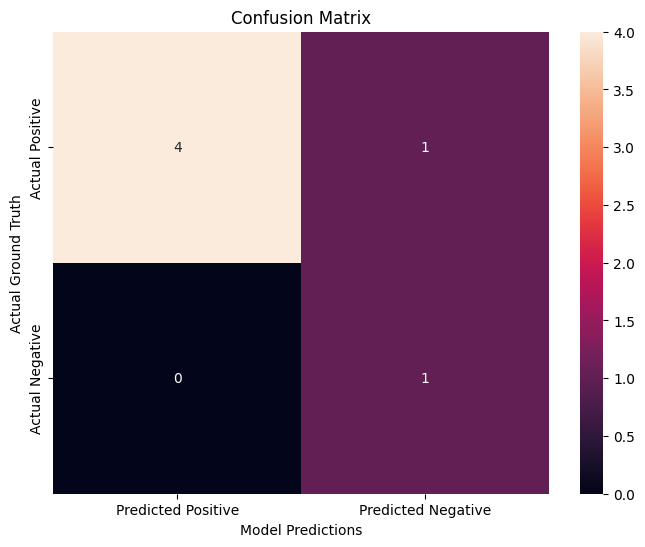

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True,
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'])

plt.title('Confusion Matrix')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')
plt.show()

Finding Individual Values

In [ ]:
TN = cm1[0][0]
FP = cm1[0][1]
FN = cm1[1][0]
TP = cm1[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 1
TN: 4
FP: 1
FN: 0


Calculating Accuracy, Precision, Recall, F-1

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (2 * precision * recall) / (precision + recall)

print("\nAccuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)
print("\nF1 Score:", f1_score)


Accuracy: 0.8333333333333334

Precision: 0.5

Recall: 1.0

F1 Score: 0.6666666666666666


2. Spending_Score", "Gender", "Purchase_Frequency" vs "Response"

In [ ]:
corr= df[["Spending_Score", "Gender", "Purchase_Frequency"]].corrwith(df["Response"])

print(corr)

Spending_Score        0.719061
Gender                0.904534
Purchase_Frequency    0.712101
dtype: float64


In [ ]:
  X = df[["Spending_Score", "Gender", "Purchase_Frequency"]]
  y = df["Response"]

  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

  model = LogisticRegression()

  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm2)
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[3 2]
 [0 1]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.33      1.00      0.50         1

    accuracy                           0.67         6
   macro avg       0.67      0.80      0.62         6
weighted avg       0.89      0.67      0.71         6



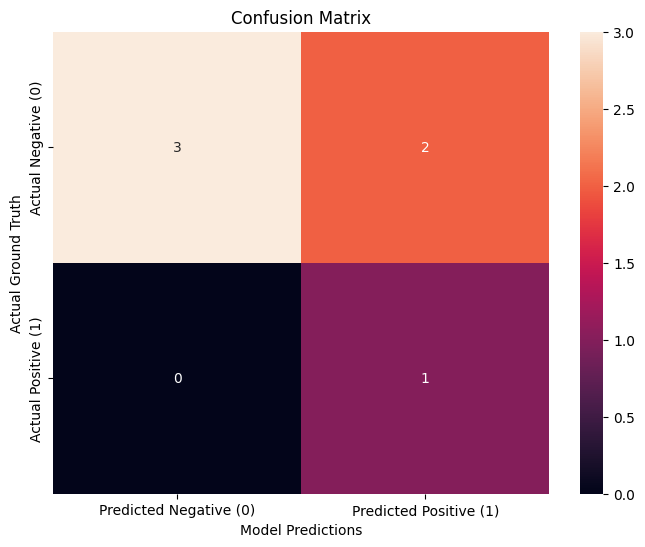

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm2,
            annot=True,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])

plt.title('Confusion Matrix')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')
plt.show()

In [ ]:
TN = cm2[0][0]
FP = cm2[0][1]
FN = cm2[1][0]
TP = cm2[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 1
TN: 3
FP: 2
FN: 0


In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (2 * precision * recall) / (precision + recall)

print("\nAccuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)
print("\nF1 Score:", f1_score)


Accuracy: 0.6666666666666666

Precision: 0.3333333333333333

Recall: 1.0

F1 Score: 0.5


# CHECKPOINT 2: MULTICLASS CLASSIFICATION

In [ ]:
X, y = make_classification(
    n_samples=300,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=3,
    random_state=42
)

print(X.shape)
print(y.shape)

(300, 4)
(300,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm3 = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm3)
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[18  8  2]
 [13 17  3]
 [ 0  5 24]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.64      0.61        28
           1       0.57      0.52      0.54        33
           2       0.83      0.83      0.83        29

    accuracy                           0.66        90
   macro avg       0.66      0.66      0.66        90
weighted avg       0.66      0.66      0.65        90



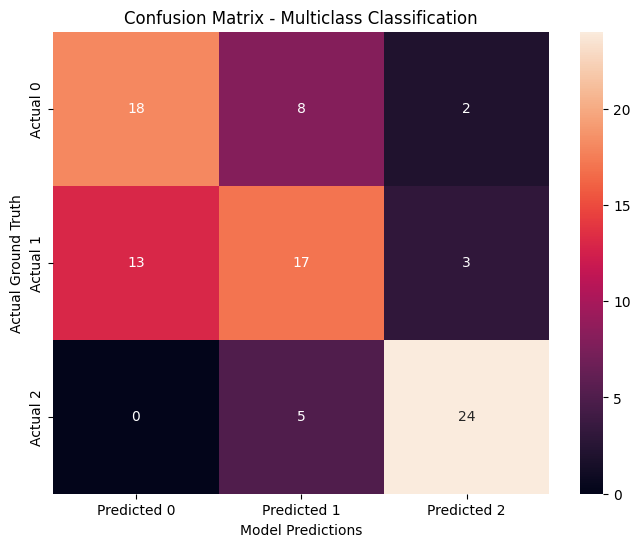

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm3,
            annot=True,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])

plt.title('Confusion Matrix - Multiclass Classification')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')
plt.show()

In [ ]:
TN = cm3[0][0]
FP = cm3[0][1]
FN = cm3[1][0]
TP = cm3[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 17
TN: 18
FP: 8
FN: 13


In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (2 * precision * recall) / (precision + recall)

print("\nAccuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)
print("\nF1 Score:", f1_score)


Accuracy: 0.625

Precision: 0.68

Recall: 0.5666666666666667

F1 Score: 0.6181818181818183


**2.**

In [ ]:
X, y = make_classification(
    n_samples=200,
    n_features=3,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

print(X.shape)
print(y.shape)

(200, 3)
(200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm4 = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm3)
print("Classification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[21  8]
 [ 2 29]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81        29
           1       0.78      0.94      0.85        31

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



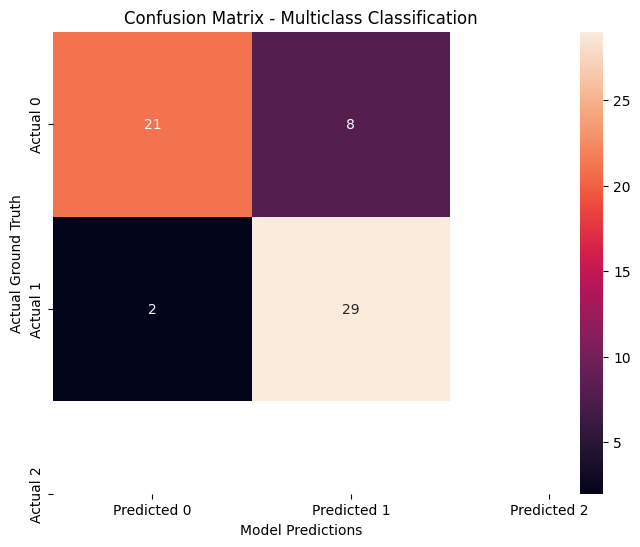

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm4,
            annot=True,
            xticklabels=['Predicted 0', 'Predicted 1', 'Predicted 2'],
            yticklabels=['Actual 0', 'Actual 1', 'Actual 2'])

plt.title('Confusion Matrix - Multiclass Classification')
plt.xlabel('Model Predictions')
plt.ylabel('Actual Ground Truth')
plt.show()

In [ ]:
TN = cm4[0][0]
FP = cm4[0][1]
FN = cm4[1][0]
TP = cm4[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 29
TN: 21
FP: 8
FN: 2


In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = (2 * precision * recall) / (precision + recall)

print("\nAccuracy:", accuracy)
print("\nPrecision:", precision)
print("\nRecall:", recall)
print("\nF1 Score:", f1_score)


Accuracy: 0.8333333333333334

Precision: 0.7837837837837838

Recall: 0.9354838709677419

F1 Score: 0.8529411764705881
